# Peramalan Kadar $NO_2$ di Daerah Manado Menggunakan KNN Regression

## Latar Belakang

Kualitas udara merupakan salah satu faktor penting yang berpengaruh terhadap kesehatan manusia dan kondisi lingkungan. Salah satu polutan udara yang perlu diperhatikan adalah Nitrogen Dioksida atau $NO_2$. Gas ini umumnya dihasilkan dari proses pembakaran bahan bakar, seperti aktivitas kendaraan bermotor, industri, dan pembangkit energi.

Pada penelitian ini, data kadar $NO_2$ digunakan dalam bentuk time series harian. Data yang digunakan adalah data selama tiga bulan, yaitu dari bulan Maret sampai Mei 2026. Dengan data time series, kadar $NO_2$ pada suatu hari dapat diprediksi berdasarkan data dari hari-hari sebelumnya.

Misalnya, untuk memprediksi kadar $NO_2$ pada hari ketiga, model dapat menggunakan data hari pertama dan hari kedua sebagai acuan. Model yang digunakan adalah KNN Regression karena target yang diprediksi berupa nilai numerik, yaitu kadar $NO_2$.

## 1. Pengumpulan Data

Tahap pertama adalah mengumpulkan data kadar $NO_2$ menggunakan layanan Copernicus Data Space Ecosystem melalui OpenEO. Data yang digunakan berasal dari koleksi Sentinel-5P Level 2 dengan band `NO2`.

Data yang diambil adalah data kadar $NO_2$ wilayah Manado selama tiga bulan, yaitu dari bulan Maret sampai Mei 2026. Sebelum menjalankan kode, pengguna perlu memiliki akun Copernicus terlebih dahulu. Setelah itu, proses autentikasi dilakukan melalui link yang muncul saat koneksi OpenEO dijalankan.

In [1]:
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.5 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Library `openeo` digunakan untuk menghubungkan Python dengan server Copernicus Data Space. Melalui library ini, data satelit dapat diakses dan diunduh menggunakan kode Python.

In [2]:
import openeo

Setelah library dipanggil, langkah berikutnya adalah membuat koneksi ke server OpenEO Copernicus. Saat kode dijalankan, sistem akan menampilkan link autentikasi. Pengguna perlu membuka link tersebut, login menggunakan akun Copernicus, lalu menyetujui akses.

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=IUCL-RDZY 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Setelah berhasil login, koneksi ke Copernicus sudah aktif. Selanjutnya, area penelitian ditentukan menggunakan polygon GeoJSON. Format koordinat yang digunakan adalah `[longitude, latitude]`.

In [4]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [124.8263984, 1.5395409],
            [124.843767, 1.5187742],
            [124.8403614, 1.4983477],
            [124.8291229, 1.4843895],
            [124.8301446, 1.468048],
            [124.818225, 1.4595368],
            [124.8914453, 1.4561323],
            [124.8948509, 1.5402218],
            [124.8263984, 1.5395409],
        ]
    ]
}

Kode berikut digunakan untuk mengambil data dari koleksi `SENTINEL_5P_L2`. Data yang diambil adalah band `NO2` dengan rentang waktu dari 1 Maret 2026 sampai 31 Mei 2026.

Pada kode OpenEO, tanggal akhir ditulis `2026-06-01` agar data bulan Mei dapat ikut terambil sampai akhir bulan. Bagian `spatial_extent` digunakan untuk membatasi wilayah pengambilan data.

In [5]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2026-03-01", "2026-06-01"],
    spatial_extent={
        "west": 124.818225,
        "south": 1.4561323,
        "east": 124.8948509,
        "north": 1.5402218
    },
    bands=["NO2"],
)

Data satelit dapat memiliki lebih dari satu pengamatan dalam satu hari. Oleh karena itu, data diagregasi menjadi data harian menggunakan nilai rata-rata. Dengan begitu, data lebih sesuai untuk analisis time series harian.

In [6]:
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

Setelah koleksi data, wilayah, dan rentang waktu ditentukan, proses pengambilan data dijalankan menggunakan `execute_batch`. Hasil pengambilan data disimpan dalam file NetCDF dengan nama `NO2Manado_Maret_Mei.nc`.

In [7]:
job = s5p_no2_daily.execute_batch(
    title="NO2 in Manado March May 2026",
    outputfile="NO2Manado_Maret_Mei.nc"
)

0:00:00 Job 'j-2606030451244889bf79790e0bfe826a': send 'start'
0:00:16 Job 'j-2606030451244889bf79790e0bfe826a': queued (progress 0%)
0:00:22 Job 'j-2606030451244889bf79790e0bfe826a': queued (progress 0%)
0:00:28 Job 'j-2606030451244889bf79790e0bfe826a': queued (progress 0%)
0:00:36 Job 'j-2606030451244889bf79790e0bfe826a': queued (progress 0%)
0:00:46 Job 'j-2606030451244889bf79790e0bfe826a': queued (progress 0%)
0:00:59 Job 'j-2606030451244889bf79790e0bfe826a': running (progress N/A)
0:01:15 Job 'j-2606030451244889bf79790e0bfe826a': running (progress N/A)
0:01:34 Job 'j-2606030451244889bf79790e0bfe826a': running (progress N/A)
0:01:58 Job 'j-2606030451244889bf79790e0bfe826a': finished (progress 100%)


## 2. Preprocessing Data

Setelah data berhasil diunduh, file yang diperoleh masih berbentuk `.nc` atau NetCDF. File ini perlu dibaca terlebih dahulu, kemudian data $NO_2$ diubah menjadi data time series harian dengan dua kolom utama, yaitu `date` dan `NO2`.

In [8]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.7 MB/s eta 0:00:00


Library `netCDF4` digunakan untuk membaca file berformat `.nc`. Selain itu, digunakan juga `numpy`, `pandas`, dan `matplotlib` untuk proses pengolahan data dan visualisasi.

In [9]:
import netCDF4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

File `NO2Manado_Maret_Mei.nc` dibaca menggunakan library `netCDF4`. Setelah file terbaca, variabel yang tersedia di dalam file akan ditampilkan.

In [11]:
file_path = "NO2Manado_Maret_Mei.nc"

ds = netCDF4.Dataset(file_path)

print("Variabel dalam file:")
print(ds.variables.keys())

Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])


Variabel yang biasanya muncul adalah `t`, `x`, `y`, `crs`, dan `NO2`. Variabel `t` berisi waktu, sedangkan `NO2` berisi data kadar Nitrogen Dioksida yang akan digunakan.

In [13]:
no2 = ds.variables["NO2"][:]

time = ds.variables["t"][:]

try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time

Data $NO_2$ pada file NetCDF berbentuk array tiga dimensi, yaitu waktu, baris wilayah, dan kolom wilayah. Oleh karena itu, perlu dilihat terlebih dahulu struktur datanya.

In [14]:
print(type(no2))

print(len(no2))
print(len(no2[0]))
print(len(no2[0][0]))

print(no2[0][0][0])

<class 'numpy.ma.MaskedArray'>
91
3
2
--


Struktur data tersebut menunjukkan bahwa setiap tanggal masih memiliki beberapa nilai $NO_2$ berdasarkan grid wilayah. Jadi, sebelum digunakan untuk modeling, data perlu dirata-ratakan agar setiap tanggal hanya memiliki satu nilai $NO_2$.

In [15]:
print("Contoh data pertama:")

for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[-- --]
 [-- --]
 [-- --]]
[[-- --]
 [-- --]
 [-- --]]
[[1.1914274182345252e-05 1.1914274182345252e-05]
 [2.1418120468297275e-06 --]
 [8.290666301036254e-06 --]]
[[5.996263553242898e-06 5.996263553242898e-06]
 [-- --]
 [-- --]]
[[-- --]
 [-- --]
 [-- --]]
[[-- 1.8844350051949732e-05]
 [-- --]
 [1.175246052298462e-05 --]]
[[-- --]
 [-- --]
 [-- --]]
[[-- --]
 [-- --]
 [-- --]]
[[3.4173444873886183e-06 --]
 [4.62401112599764e-06 2.2682370399706997e-06]
 [-- --]]
[[-- --]
 [-- --]
 [-- --]]


Pada data $NO_2$, terdapat kemungkinan nilai kosong atau missing value. Missing value biasanya muncul karena tidak semua grid wilayah memiliki data pada waktu tertentu. Nilai kosong tersebut perlu diisi agar data time series menjadi lengkap.

In [16]:
no2_array = np.ma.filled(no2, np.nan)

no2_filled = np.zeros_like(no2_array, dtype=float)

for i in range(no2_array.shape[1]):
    for j in range(no2_array.shape[2]):
        series = pd.Series(no2_array[:, i, j])
        no2_filled[:, i, j] = series.interpolate(
            method="linear",
            limit_direction="both"
        ).to_numpy()

print("Jumlah missing setelah interpolasi:", np.isnan(no2_filled).sum())

Jumlah missing setelah interpolasi: 0


Missing value diisi menggunakan interpolasi linear. Metode ini memperkirakan nilai kosong berdasarkan pola nilai sebelum dan sesudahnya. Setelah itu, data $NO_2$ dirata-ratakan untuk setiap tanggal.

In [17]:
new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime("%Y-%m-%d")
    new_dates.append(new_date)

    new_no2.append(np.mean(no2_filled[i]))

Hasil rata-rata $NO_2$ kemudian disimpan ke dalam dataframe. Dataframe ini hanya berisi dua kolom, yaitu `date` sebagai tanggal dan `NO2` sebagai nilai rata-rata kadar Nitrogen Dioksida harian.

In [19]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

df.to_csv("NO2_Manado_Maret_Mei_timeseries.csv", index=False)

df.head()

,date,NO2
0,2026-03-01,0.000009
1,2026-03-02,0.000009
2,2026-03-03,0.000009
3,2026-03-04,0.000007
4,2026-03-05,0.000008


Setelah data disimpan menjadi CSV, dilakukan pengecekan apakah seluruh tanggal harian sudah lengkap. Jika ada tanggal yang hilang, maka tanggal tersebut akan terdeteksi sebagai missing date.

In [20]:
df = pd.read_csv("NO2_Manado_Maret_Mei_timeseries.csv")

df["date"] = pd.to_datetime(df["date"])

start_date = df["date"].min()
end_date = df["date"].max()

full_range = pd.date_range(start=start_date, end=end_date, freq="D")

missing_dates = full_range.difference(df["date"])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 1
Daftar tanggal missing:
DatetimeIndex(['2026-04-15'], dtype='datetime64[ns]', freq='D')


Jika terdapat tanggal yang hilang, maka data dibuat ulang berdasarkan rentang tanggal lengkap. Tanggal yang belum memiliki nilai $NO_2$ akan diisi menggunakan interpolasi berdasarkan waktu.

In [21]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

full_range = pd.date_range(start=start_date, end=end_date, freq="D")

df = df.set_index("date").reindex(full_range)
df.index.name = "date"

df["NO2"] = df["NO2"].interpolate(method="time")

df["NO2"] = df["NO2"].bfill().ffill()

df.to_csv("no2_manado_maret_mei_interpolated.csv")

df.head()

,NO2
date,
2026-03-01,0.000009
2026-03-02,0.000009
2026-03-03,0.000009
2026-03-04,0.000007
2026-03-05,0.000008


Setelah proses interpolasi tanggal hilang selesai, data dicek kembali untuk memastikan bahwa tidak ada lagi tanggal yang kosong.

In [22]:
df_check = pd.read_csv("no2_manado_maret_mei_interpolated.csv")

df_check["date"] = pd.to_datetime(df_check["date"])

full_range_check = pd.date_range(
    start=df_check["date"].min(),
    end=df_check["date"].max(),
    freq="D"
)

missing_dates_check = full_range_check.difference(df_check["date"])

print(f"Jumlah hari missing: {len(missing_dates_check)}")
print("Daftar tanggal missing:")
print(missing_dates_check)

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


Tahap berikutnya adalah mendeteksi outlier menggunakan metode IQR. Outlier adalah nilai yang terlalu jauh dari pola data umum. Nilai seperti ini perlu diperiksa karena dapat memengaruhi proses pelatihan model.

In [23]:
df = pd.read_csv("no2_manado_maret_mei_interpolated.csv")

df["date"] = pd.to_datetime(df["date"])

Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[["date", "NO2"]].head())

Jumlah Outlier (IQR): 3
         date       NO2
34 2026-04-04  0.000016
38 2026-04-08  0.000002
39 2026-04-09  0.000004


Outlier divisualisasikan agar posisi nilai ekstrem dapat terlihat pada grafik. Titik merah menunjukkan data yang terdeteksi sebagai outlier, sedangkan garis batas menunjukkan batas atas dan batas bawah berdasarkan metode IQR.

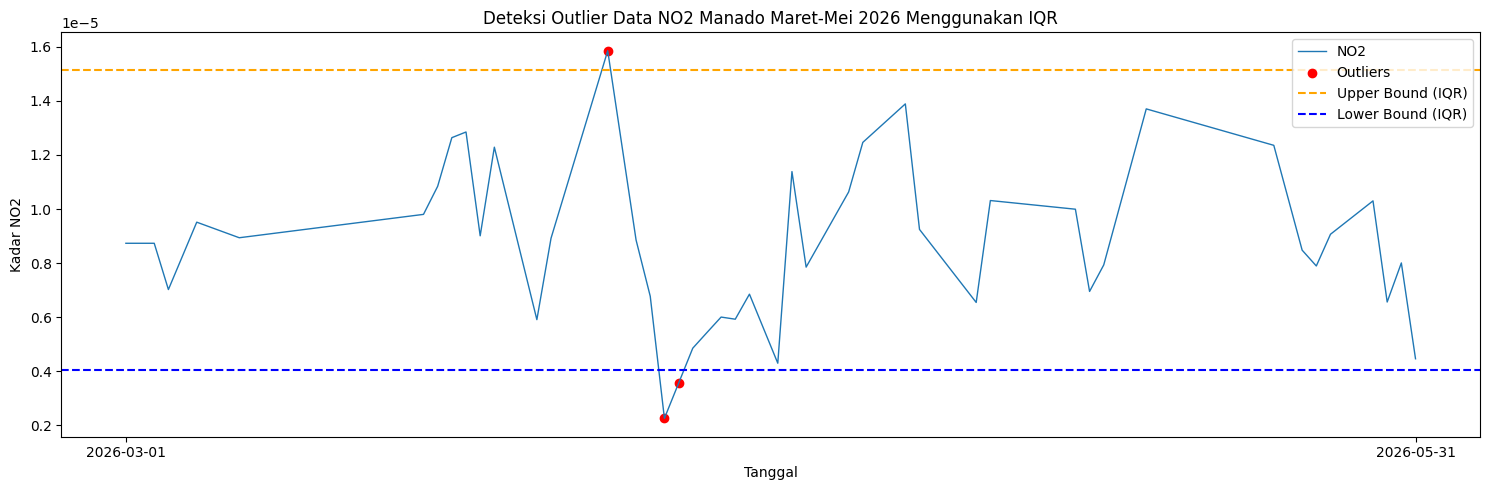

In [24]:
plt.figure(figsize=(15, 5))
plt.plot(df["date"], df["NO2"], label="NO2", linewidth=1)

plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["NO2"],
    color="red",
    marker="o",
    label="Outliers"
)

plt.axhline(
    upper_bound,
    color="orange",
    linestyle="dashed",
    label="Upper Bound (IQR)"
)

plt.axhline(
    lower_bound,
    color="blue",
    linestyle="dashed",
    label="Lower Bound (IQR)"
)

plt.title("Deteksi Outlier Data NO2 Manado Maret-Mei 2026 Menggunakan IQR")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()

plt.xticks(
    ticks=[df["date"].iloc[0], df["date"].iloc[-1]],
    labels=[
        df["date"].iloc[0].strftime("%Y-%m-%d"),
        df["date"].iloc[-1].strftime("%Y-%m-%d")
    ]
)

plt.show()

Outlier tidak langsung dihapus dari urutan data. Karena data ini merupakan time series, maka outlier ditandai sebagai nilai kosong, lalu diisi kembali menggunakan interpolasi linear agar urutan tanggal tetap lengkap.

In [34]:
df["NO2_cleaned"] = df["NO2"].mask(
    (df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)
)

print("Jumlah nilai yang dinyatakan sebagai outlier:", df["NO2_cleaned"].isna().sum())

df["NO2_filled"] = df["NO2_cleaned"].interpolate(method="linear")

df["NO2_filled"] = df["NO2_filled"].bfill().ffill()

print("Jumlah missing setelah interpolasi:", df["NO2_filled"].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 3
Jumlah missing setelah interpolasi: 0


Setelah outlier ditangani, data divisualisasikan kembali. Grafik ini menunjukkan kondisi data $NO_2$ setelah missing value dan outlier diproses.

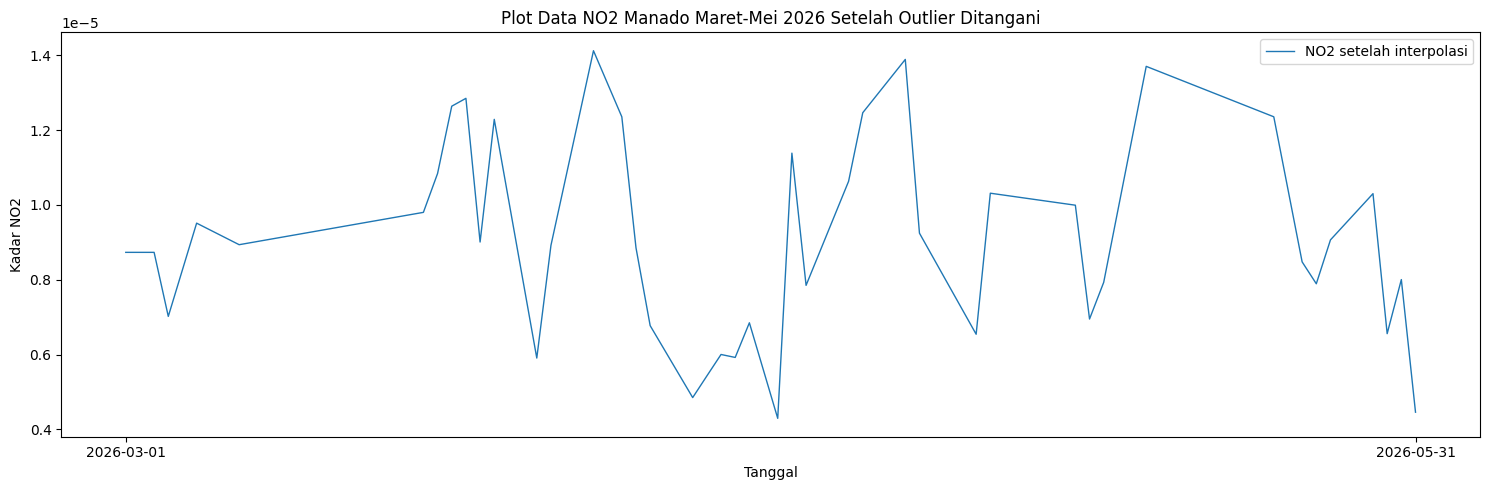

In [32]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["date"],
    df["NO2_filled"],
    label="NO2 setelah interpolasi",
    linewidth=1
)

plt.xticks(
    ticks=[df["date"].iloc[0], df["date"].iloc[-1]],
    labels=[
        df["date"].iloc[0].strftime("%Y-%m-%d"),
        df["date"].iloc[-1].strftime("%Y-%m-%d")
    ]
)

plt.title("Plot Data NO2 Manado Maret-Mei 2026 Setelah Outlier Ditangani")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

Data akhir hasil preprocessing disimpan ke dalam file CSV. File ini akan digunakan pada tahap modeling.

In [35]:
df_final = df[["date", "NO2_filled"]].rename(
    columns={"NO2_filled": "NO2"}
)

df_final.to_csv("NO2_Manado_Maret_Mei_final.csv", index=False)

df_final.head()

,date,NO2
0,2026-03-01,0.000009
1,2026-03-02,0.000009
2,2026-03-03,0.000009
3,2026-03-04,0.000007
4,2026-03-05,0.000008


## 3. Modeling Menggunakan KNN Regression

Pada tahap modeling, data time series diubah menjadi data supervised. Artinya, data yang awalnya hanya berisi tanggal dan kadar $NO_2$ akan diubah menjadi data dengan fitur dan target.

Konsepnya adalah nilai $NO_2$ pada suatu hari diprediksi berdasarkan nilai $NO_2$ pada hari-hari sebelumnya. Misalnya, untuk memprediksi kadar $NO_2$ hari ketiga, model menggunakan data hari pertama dan hari kedua.

Bentuk sederhananya adalah:

$NO_2(t-2), NO_2(t-1) \rightarrow NO_2(t)$

Artinya, dua hari sebelumnya digunakan sebagai fitur, sedangkan hari ini menjadi target yang diprediksi.

In [36]:
df = pd.read_csv("NO2_Manado_Maret_Mei_final.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,NO2
0,2026-03-01,0.000009
1,2026-03-02,0.000009
2,2026-03-03,0.000009
3,2026-03-04,0.000007
4,2026-03-05,0.000008


Sebelum digunakan pada model KNN Regression, data perlu dinormalisasi. Hal ini karena KNN bekerja berdasarkan jarak antar data. Dengan normalisasi, nilai $NO_2$ diubah ke rentang 0 sampai 1.

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["NO2_scaled"] = scaler.fit_transform(df[["NO2"]])

df.head()

,date,NO2,NO2_scaled
0,2026-03-01,0.000009,0.451507
1,2026-03-02,0.000009,0.451507
2,2026-03-03,0.000009,0.451507
3,2026-03-04,0.000007,0.277316
4,2026-03-05,0.000008,0.404135


Selanjutnya dibuat fungsi untuk mengubah data time series menjadi data supervised. Parameter `n_lag` digunakan untuk menentukan berapa banyak hari sebelumnya yang dipakai sebagai fitur.

In [38]:
def create_supervised(data, n_lag=2):
    df_supervised = pd.DataFrame()

    for i in range(n_lag, 0, -1):
        df_supervised[f"NO2(t-{i})"] = data.shift(i)

    df_supervised["NO2(t)"] = data

    df_supervised.dropna(inplace=True)

    return df_supervised

Pada contoh pertama, data dibuat menggunakan dua hari sebelumnya. Dengan begitu, model akan mempelajari hubungan antara nilai $NO_2$ dua hari sebelumnya dengan nilai $NO_2$ hari ini.

In [40]:
supervised_df2 = create_supervised(df["NO2_scaled"], n_lag=2)

print(supervised_df2)
print(supervised_df2.shape)

    NO2(t-2)  NO2(t-1)    NO2(t)
2   0.451507  0.451507  0.451507
3   0.451507  0.451507  0.277316
4   0.451507  0.277316  0.404135
5   0.277316  0.404135  0.530955
6   0.404135  0.530955  0.511416
..       ...       ...       ...
87  0.485456  0.527360  0.569264
88  0.527360  0.569264  0.611168
89  0.569264  0.611168  0.230336
90  0.611168  0.230336  0.377453
91  0.230336  0.377453  0.016654

[90 rows x 3 columns]
(90, 3)


Sebagai pembanding, data juga dibuat menggunakan empat hari sebelumnya. Tujuannya untuk melihat apakah penambahan jumlah hari sebelumnya dapat membantu model dalam melakukan prediksi.

In [41]:
supervised_df4 = create_supervised(df["NO2_scaled"], n_lag=4)

print(supervised_df4)
print(supervised_df4.shape)

    NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4   0.451507  0.451507  0.451507  0.277316  0.404135
5   0.451507  0.451507  0.277316  0.404135  0.530955
6   0.451507  0.277316  0.404135  0.530955  0.511416
7   0.277316  0.404135  0.530955  0.511416  0.491877
8   0.404135  0.530955  0.511416  0.491877  0.472337
..       ...       ...       ...       ...       ...
87  0.425590  0.366079  0.485456  0.527360  0.569264
88  0.366079  0.485456  0.527360  0.569264  0.611168
89  0.485456  0.527360  0.569264  0.611168  0.230336
90  0.527360  0.569264  0.611168  0.230336  0.377453
91  0.569264  0.611168  0.230336  0.377453  0.016654

[88 rows x 5 columns]
(88, 5)


Selain dua dan empat hari sebelumnya, dibuat juga data dengan sepuluh hari sebelumnya. Perbandingan ini digunakan untuk melihat pengaruh jumlah lag terhadap performa model.

In [42]:
supervised_df10 = create_supervised(df["NO2_scaled"], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

    NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10   0.451507  0.451507  0.451507  0.277316  0.404135  0.530955  0.511416   
11   0.451507  0.451507  0.277316  0.404135  0.530955  0.511416  0.491877   
12   0.451507  0.277316  0.404135  0.530955  0.511416  0.491877  0.472337   
13   0.277316  0.404135  0.530955  0.511416  0.491877  0.472337  0.479104   
14   0.404135  0.530955  0.511416  0.491877  0.472337  0.479104  0.485870   
..        ...       ...       ...       ...       ...       ...       ...   
87   0.881233  0.865991  0.850749  0.835508  0.820266  0.622928  0.425590   
88   0.865991  0.850749  0.835508  0.820266  0.622928  0.425590  0.366079   
89   0.850749  0.835508  0.820266  0.622928  0.425590  0.366079  0.485456   
90   0.835508  0.820266  0.622928  0.425590  0.366079  0.485456  0.527360   
91   0.820266  0.622928  0.425590  0.366079  0.485456  0.527360  0.569264   

    NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10  0.491877  0.472337  0.4791

Sebelum model dilatih, dilakukan uji korelasi untuk melihat hubungan antara nilai $NO_2$ pada hari-hari sebelumnya dengan nilai $NO_2$ hari ini. Semakin besar nilai korelasi, maka hubungan antara fitur dan target semakin kuat.

In [43]:
supervised_df30 = create_supervised(df["NO2_scaled"], n_lag=30)

lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30["NO2(t)"])

print(correlations)

NO2(t-30)   -0.071776
NO2(t-29)   -0.011945
NO2(t-28)   -0.007655
NO2(t-27)   -0.021922
NO2(t-26)   -0.055847
NO2(t-25)   -0.046794
NO2(t-24)   -0.000248
NO2(t-23)    0.088565
NO2(t-22)    0.097812
NO2(t-21)    0.176751
NO2(t-20)    0.163777
NO2(t-19)    0.050618
NO2(t-18)   -0.057126
NO2(t-17)   -0.126606
NO2(t-16)   -0.220130
NO2(t-15)   -0.271711
NO2(t-14)   -0.275677
NO2(t-13)   -0.313620
NO2(t-12)   -0.236333
NO2(t-11)   -0.177172
NO2(t-10)   -0.131185
NO2(t-9)    -0.078099
NO2(t-8)    -0.028471
NO2(t-7)    -0.039902
NO2(t-6)    -0.025265
NO2(t-5)     0.029513
NO2(t-4)     0.126484
NO2(t-3)     0.341121
NO2(t-2)     0.589209
NO2(t-1)     0.772270
dtype: float64


Setelah data supervised dibuat, tahap berikutnya adalah training model menggunakan KNN Regression. Model ini digunakan karena target yang diprediksi berupa nilai numerik, yaitu kadar $NO_2$.

In [44]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

MAPE digunakan untuk menghitung rata-rata persentase kesalahan prediksi. Semakin kecil nilai MAPE, maka semakin baik hasil prediksi model.

In [45]:
def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    nonzero = y_true != 0

    return np.mean(
        np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])
    ) * 100

Fungsi berikut digunakan untuk melatih model KNN Regression. Data dibagi menjadi data latih dan data uji dengan perbandingan 80:20. Karena data yang digunakan adalah time series, data tidak diacak agar urutan waktunya tetap terjaga.

In [46]:
def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=["NO2(t)"]).values
    y = df_supervised["NO2(t)"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)}")
    print(f"Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred

Model dilatih menggunakan tiga variasi data, yaitu dua hari sebelumnya, empat hari sebelumnya, dan sepuluh hari sebelumnya. Hasil dari ketiga model ini dapat dibandingkan untuk melihat jumlah lag mana yang menghasilkan prediksi lebih baik.

In [47]:
knn_2, y_test_2, y_pred_2 = train_knn(
    supervised_df2,
    "KNN - 2 Hari Sebelumnya"
)

knn_4, y_test_4, y_pred_4 = train_knn(
    supervised_df4,
    "KNN - 4 Hari Sebelumnya"
)

knn_10, y_test_10, y_pred_10 = train_knn(
    supervised_df10,
    "KNN - 10 Hari Sebelumnya"
)


=== KNN - 2 Hari Sebelumnya ===
Train Size: 72
Test Size: 18
RMSE: 0.203501
R² Score: 0.3942
MAPE: 180.6545%

=== KNN - 4 Hari Sebelumnya ===
Train Size: 70
Test Size: 18
RMSE: 0.209614
R² Score: 0.3572
MAPE: 184.2969%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 65
Test Size: 17
RMSE: 0.336793
R² Score: -0.7022
MAPE: 221.0690%


Grafik berikut menampilkan perbandingan antara nilai aktual dan nilai prediksi pada model KNN dengan dua hari sebelumnya.

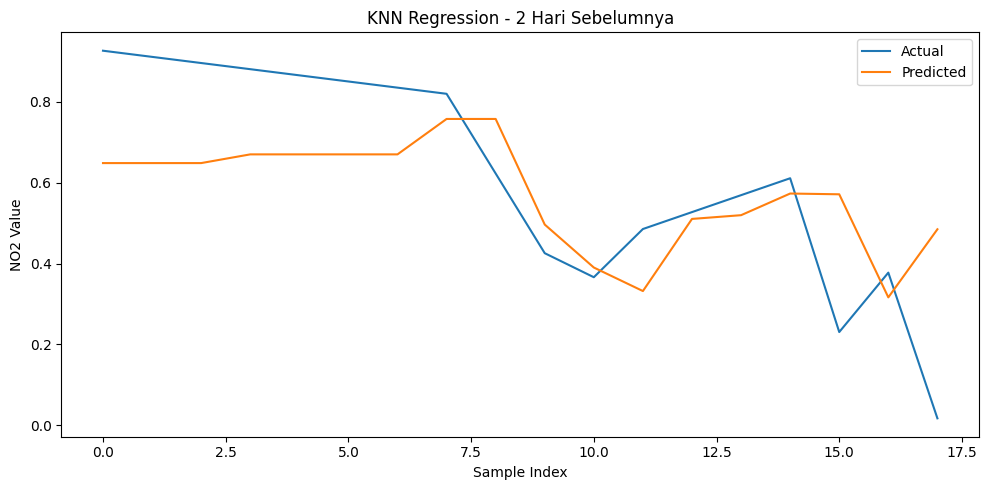

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(np.arange(len(y_test_2)), y_test_2, label="Actual")
plt.plot(np.arange(len(y_pred_2)), y_pred_2, label="Predicted")

plt.title("KNN Regression - 2 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.tight_layout()
plt.show()

Grafik berikut menampilkan hasil prediksi model KNN dengan empat hari sebelumnya sebagai fitur.

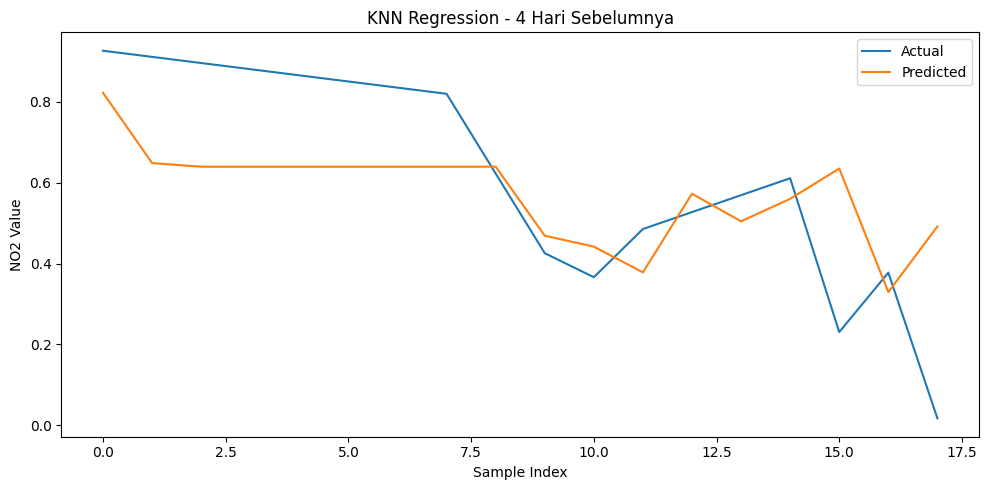

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")

plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.tight_layout()
plt.show()

Grafik berikut menampilkan hasil prediksi model KNN dengan sepuluh hari sebelumnya sebagai fitur.

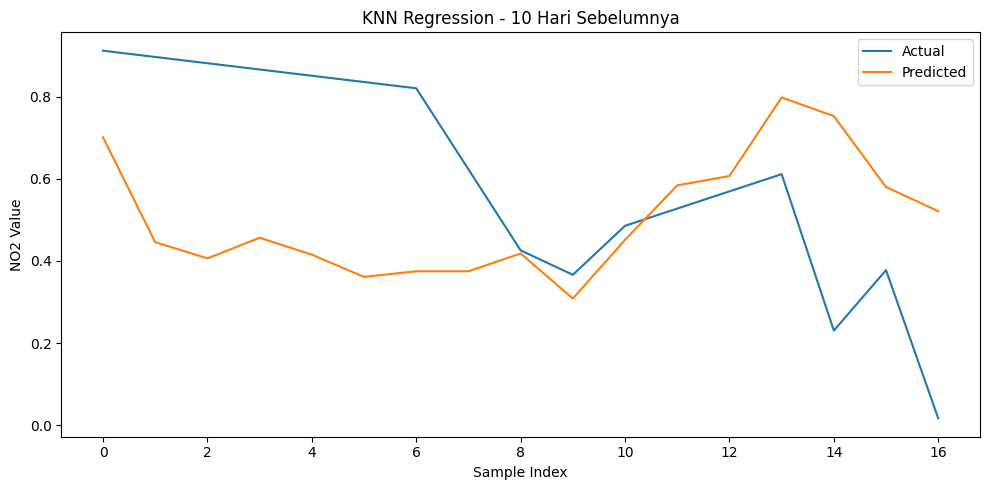

In [50]:
plt.figure(figsize=(10, 5))

plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")

plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.tight_layout()
plt.show()

## Kesimpulan Sementara

Data kadar $NO_2$ berhasil dikumpulkan dari Copernicus untuk periode Maret sampai Mei 2026. Data awal yang berbentuk NetCDF diproses menjadi data time series harian dalam format CSV dengan dua kolom utama, yaitu `date` dan `NO2`.

Pada tahap preprocessing, missing value, missing date, dan outlier ditangani menggunakan interpolasi agar data tetap lengkap berdasarkan urutan waktu. Setelah itu, data time series diubah menjadi data supervised menggunakan konsep lag.

Konsep lag digunakan karena kadar $NO_2$ pada suatu hari dapat dipengaruhi oleh kadar $NO_2$ pada hari-hari sebelumnya. Misalnya, kadar $NO_2$ hari ketiga dapat diprediksi berdasarkan kadar $NO_2$ hari pertama dan kedua.

Model yang digunakan adalah KNN Regression karena model ini dapat memprediksi nilai numerik. Hasil evaluasi dari beberapa variasi jumlah hari sebelumnya dapat dibandingkan untuk menentukan jumlah lag yang memberikan hasil prediksi paling baik.